# ME310 Numerical Methods: Neural Network Optimization Basics

This handout is prepared by Atakan Aygun for ME310:Numerical Methods course in Spring26. The main aim is to introduce neural networks as an optimization tool for the "Optimization" chapter in ME310.

In our **ME310: Numerical Methods** course, you have explored optimization as the process of finding the minimum (or maximum) of a function $f(\mathbf{x})$ by iteratively updating variables. In mechanical systems, this might mean finding the configuration of least potential energy or the optimal dimensions of a beam to minimize weight.

**Neural Network training** is, at its core, an optimization problem. Instead of physical dimensions, we optimize **weights** and **biases** (the model parameters). We define a **Loss Function** (often Mean Squared Error), which measures the discrepancy between the model's prediction and the observed data.

To '*train*' the network, we use numerical algorithms like **Stochastic Gradient Descent (SGD)** or **Adam** to navigate the high-dimensional parameter space and find the minimum loss. The 'learning' you see in AI is simply the convergence of these numerical solvers.

# Case 1: Neural Network Optimization Basics

In this notebook, first we will explore how to solve a simple Linear Regression problem using PyTorch. This is the simplest form of a 'Neural Network' (a single neuron with a linear activation).

Approximate the parameters $m$ and $n$ for the equation $y = mx + n$ given noisy data.

#### Generate the data
In the following code block, we will generate synthetic data to demonstrate linear regression. We first import PyTorch using:

```python
import torch
```

The subsequent logic is designed to automatically detect and utilize a GPU (Graphics Processing Unit) if your Google Colab runtime is configured with one, significantly accelerating the numerical computations. Otherwise, it defaults to the standard CPU. **Warning**: The GPU Runtimes are limited. So if you do not perform anything, I recommend you to disconnect the runtime.

The generated data is sampled from the line $y=2.5x + 1.0$ and we introduce a random noise to disturb the data.

cuda available


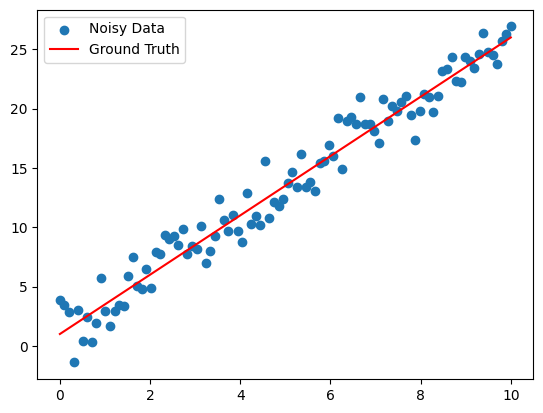

In [ ]:
import torch
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    """ Cuda support """
    print('cuda available')
    device = torch.device('cuda')
else:
    print('cuda not available')
    device = torch.device('cpu')

# Generate Synthetic Data
torch.manual_seed(42)
True_m = 2.5
True_n = 1.0

N = 100 # Number of data points

X = torch.linspace(0, 10, N).reshape(-1, 1)
noise = torch.randn(X.shape) * 1.5
Y = True_m * X + True_n + noise

plt.scatter(X.numpy(), Y.numpy(), label='Noisy Data')
plt.plot(X.numpy(), True_m * X.numpy() + True_n, color='red', label='Ground Truth')
plt.legend()
plt.show()

#### Create the neuron

Next, we will define our single neuron using the neural network library of PyTorch
```python
import torch.nn as nn
```
The linear model will have one input $x$, and one output $y$. When you define a neuron (or a network) in PyTorch it automatically initalizes the weights and biases.

In [ ]:
import torch.nn as nn

# Define the Linear Model
# nn.Linear(input_dim, output_dim) implements y = xA^T + b
model = nn.Linear(1, 1)

print(f"Initial Weights (m): {model.weight.item():.4f}")
print(f"Initial Bias (n): {model.bias.item():.4f}")

Initial Weights (m): -0.4309
Initial Bias (n): -0.5987


#### Set up the Loss function and Optimizer
PyTorch has multiple definitions of the loss functions and optimizers. The most common loss function in neural networks is the 'Mean Squared Error'. This error term finds the mean squared error between the prediction $\hat{y}$ and the true value $y$ and defined as

$\frac{1}{N}\sum_{i=0}^{N}|\hat{y} - y|^2$

We select the optimizer from PyTorch as the 'Stochastic Gradient Descent' (SGD) with a learning rate of 0.01. Learning rate is a parameter that determines the step size taken during gradient descent, controlling how quickly or slowly a model learns.

In [ ]:
import torch.optim as optim

# Optimization Setup
criterion = nn.MSELoss()  # Mean Squared Error
optimizer = optim.SGD(model.parameters(), lr=0.01) # Learning rate

#### Train the Model
We will train our model for a specified number of *epochs*. An epoch is a single complete pass of the entire training dataset through a machine learning model, allowing it to update parameters (weights and biases).

In [ ]:
epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass: compute predicted y by passing x to the model
    Y_pred = model(X)

    # Compute loss
    loss = criterion(Y_pred, Y)
    losses.append(loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

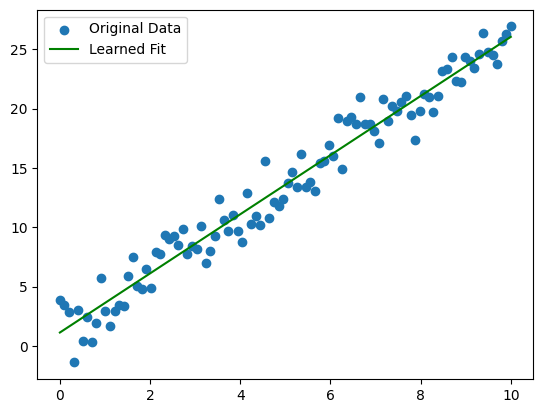

In [ ]:
# Compare results
with torch.no_grad():
    final_pred = model(X).numpy()

plt.scatter(X, Y, label='Original Data')
plt.plot(X, final_pred, color='green', label='Learned Fit')
plt.legend()
plt.show()

The model is trained and it resulted in a function. We can check if the model parameters are close to the original parameters after the training.

In [ ]:
print(f"Final Learned Weight (m): {model.weight.item():.4f}")
print(f"Final Learned Bias (n): {model.bias.item():.4f}")

print(f"\nTrue m: {True_m}")
print(f"True n: {True_n}")

Final Learned Weight (m): 2.4925
Final Learned Bias (n): 1.1251

True m: 2.5
True n: 1.0


# Case 2: Non-Linear Regression with a Deep Neural Network

In this section, we expand from a single neuron to a Multi-Layer Perceptron (MLP). This allows the model to learn complex, non-linear mappings by stacking linear layers and non-linear activation functions (like ReLU).

#### Generate the Data
Let's generate a data from a sine wave.

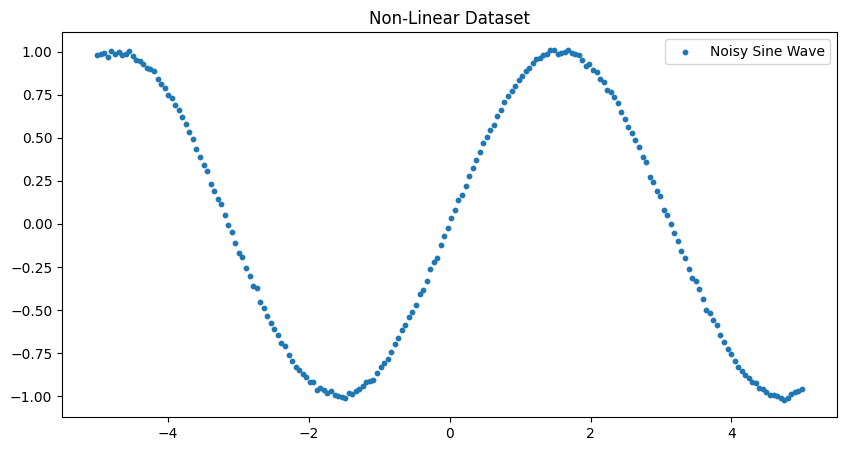

In [ ]:
# Generate Non-linear Synthetic Data (Sine Wave)
torch.manual_seed(42)
X_nonlin = torch.linspace(-5, 5, 200).reshape(-1, 1)
Y_nonlin = torch.sin(X_nonlin) + torch.randn(X_nonlin.shape) * 0.01

plt.figure(figsize=(10, 5))
plt.scatter(X_nonlin.numpy(), Y_nonlin.numpy(), s=10, label='Noisy Sine Wave')
plt.title('Non-Linear Dataset')
plt.legend(loc='upper right')
plt.show()

#### Define the Neural Network
For the nonlinear case, we need to define multiple neurons. We will create our ```SimpleNet``` class using Pytorch ```nn``` module.
In this code block, the weights are initialized with Xavier initialization to show you there are different methods to initialize neural networks.

In [ ]:
# Define a Small Deep Network
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 20),      # Input layer to 1st hidden layer
            nn.ReLU(),
            nn.Linear(20, 20),     # 2nd hidden layer
            nn.ReLU(),
            nn.Linear(20, 20),     # 3rd hidden layer
            nn.ReLU(),
            nn.Linear(20, 1)       # Output layer
        )

        torch.nn.init.xavier_normal_(self.layers[0].weight)
        torch.nn.init.zeros_(self.layers[0].bias)

    def forward(self, x):
        return self.layers(x)

model_nonlin = SimpleNet()

#### Activation functions
In the above block, the ```nn.ReLU()``` blocks try to introduce nonlinearities to the network. A deep neural network layer can be written in mathematical form as

$\hat{y} = σ(\mathbf{W}\mathbf{x})+\mathbf{b}$,

where the function $σ$ is named as the '*activation function*'. We selected the 'Rectified Linear Unit' or ReLU for this application. The ReLU function can be seen below.

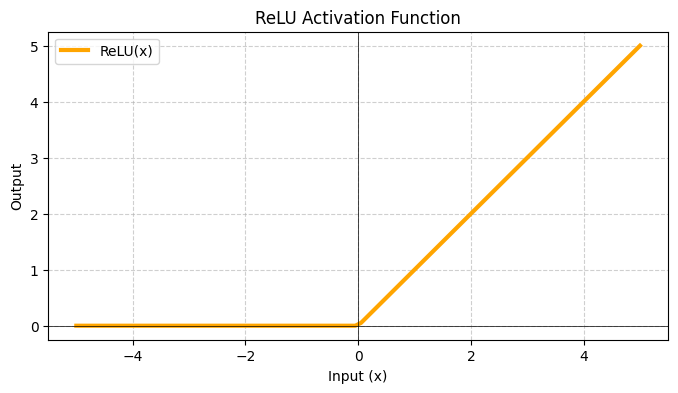

In [ ]:
# Define a range of values
x = torch.linspace(-5, 5, 100)
# Apply ReLU: f(x) = max(0, x)
relu = torch.nn.ReLU()
y = relu(x)

plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), y.numpy(), label='ReLU(x)', color='orange', linewidth=3)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.title('ReLU Activation Function')
plt.xlabel('Input (x)')
plt.ylabel('Output')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

#### Train the Network
Let's train this deep neural network by setting our loss function and optimizer. The loss function is defined as mean squared error again, and the optimizer is selected as the Adam (Adaptive Moment Estimation) algorithm. This is the most common optimizer for deep neural networks.

Epoch [250/5000], Loss: 0.003668
Epoch [500/5000], Loss: 0.000902
Epoch [750/5000], Loss: 0.000473
Epoch [1000/5000], Loss: 0.000345
Epoch [1250/5000], Loss: 0.000395
Epoch [1500/5000], Loss: 0.000284
Epoch [1750/5000], Loss: 0.000271
Epoch [2000/5000], Loss: 0.000258
Epoch [2250/5000], Loss: 0.002300
Epoch [2500/5000], Loss: 0.000251
Epoch [2750/5000], Loss: 0.000951
Epoch [3000/5000], Loss: 0.000244
Epoch [3250/5000], Loss: 0.000309
Epoch [3500/5000], Loss: 0.000325
Epoch [3750/5000], Loss: 0.000239
Epoch [4000/5000], Loss: 0.000241
Epoch [4250/5000], Loss: 0.000247
Epoch [4500/5000], Loss: 0.000237
Epoch [4750/5000], Loss: 0.000235
Epoch [5000/5000], Loss: 0.000262


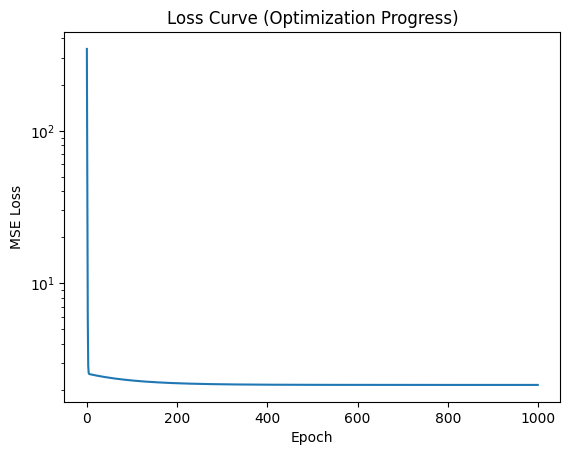

In [ ]:
# Optimization Setup for Non-linear Task
criterion_nonlin = nn.MSELoss()
# Using a slightly smaller learning rate with more epochs for smoother convergence
optimizer_nonlin = optim.Adam(model_nonlin.parameters(), lr=0.005)

epochs_nonlin = 5000
losses_nonlin = []

for epoch in range(epochs_nonlin):
    # Forward pass
    Y_pred = model_nonlin(X_nonlin)
    loss = criterion_nonlin(Y_pred, Y_nonlin)
    losses_nonlin.append(loss.item())

    # Backward and optimize
    optimizer_nonlin.zero_grad()
    loss.backward()
    optimizer_nonlin.step()

    if (epoch+1) % 250 == 0:
        print(f'Epoch [{epoch+1}/{epochs_nonlin}], Loss: {loss.item():.6f}')

plt.semilogy(losses)
plt.title('Loss Curve (Optimization Progress)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

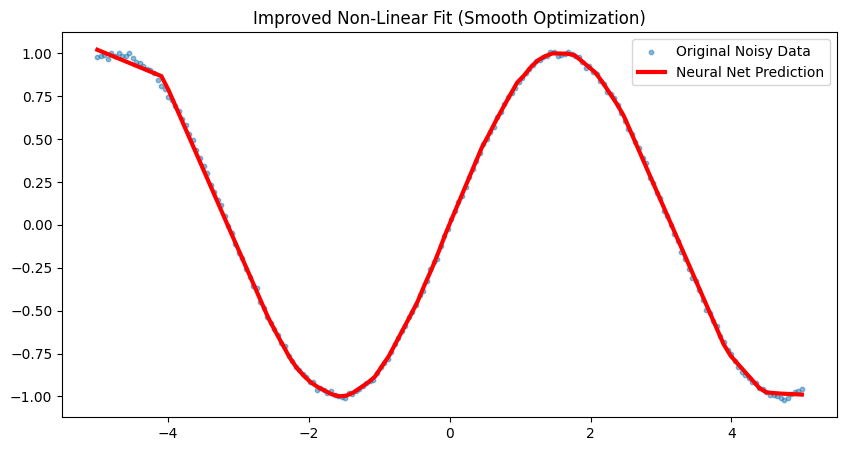

In [ ]:
# Visualize Results with smoother interpolation
with torch.no_grad():
    X_test = torch.linspace(-5, 5, 100).reshape(-1, 1)
    final_pred_nonlin = model_nonlin(X_test).numpy()

plt.figure(figsize=(10, 5))
plt.scatter(X_nonlin, Y_nonlin, s=10, alpha=0.5, label='Original Noisy Data')
plt.plot(X_test, final_pred_nonlin, color='red', linewidth=3, label='Neural Net Prediction')
plt.title('Improved Non-Linear Fit (Smooth Optimization)')
plt.legend()
plt.show()

# Case 3: Introduction to Physics-Informed Neural Networks (PINNs)

In mechanical engineering, we often know the underlying physics governing a system, typically expressed as Partial Differential Equations (PDEs). A **Physics-Informed Neural Network (PINN)** embeds these equations directly into the loss function, allowing the model to learn solutions that satisfy physical laws even with little or no labeled data. It tries the minimize the residual of a PDE and boundary/initial condition values, makng it an optimization problem.

#### 2D Steady Heat Equation

We will solve the Laplace equation for temperature $T(x, y)$ as a model problem in a unit square domain $[0,1] \times [0,1]$:
$$\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} = 0$$

with boundary conditions:
<!-- #### Boundary Conditions (BCs): -->
*   **Bottom:** $T(x, 0) = 0$
*   **Top:** $T(x, 1) = \sin(\pi x)$
*   **Left:** $T(0, y) = 0$
*   **Right:** $T(1, y) = 0$

<!-- #### Exact Analytical Solution: -->
For these specific boundary conditions, the exact solution is given by:
$$T(x, y) = \sin(\pi x) \frac{\sinh(\pi y)}{\sinh(\pi)}$$

In the following cells, the PINN will attempt to satisfy the PDE and the BCs simultaneously by minimizing a composite loss function.

#### Design the Network
We will create a simple 2 layer network in our ```HeatPINN``` class. The activation function here is the hyperbolic tangent function for including nonlinearity to the solution. We cannot use ReLU here since we need second order derivatives for the heat equation and ReLU vanishes if you get the second order derivative. We select the Adam optimizer again for our optimization problem.

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class HeatPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 1)
        )

        # Xavier Initialization
        # torch.nn.init.xavier_normal_(self.net[0].weight)
        # torch.nn.init.zeros_(self.net[0].bias)

    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))

# Instantiate model and optimizer
pinn_model = HeatPINN()
optimizer_pinn = torch.optim.Adam(pinn_model.parameters(), lr=0.001)

#### Define the Loss Function with PDE Residual
We can solve a PDE numerically by trying to minimize the residual. However, a PDE consists of derivatives. In the following chapters in this course, you will see different ways to obtain numerical derivatives. For PINNs, we can utilize *[automatic differentiation](https://en.wikipedia.org/wiki/Automatic_differentiation)*. Automatic differentiation applies the chain rule repeatedly to the elementary functions and arithmetic operations to achieve the derivative of the overall composition. It is implemented in popular deep learning frameworks, and we will use ```torch.autograd.grad()``` function to calculate the derivatives. We can define the PDE Loss as

$\mathcal{L}_{PDE} = \frac{1}{N_R} \sum_{i=1}^{N_R} |T_{xx}^i + T_{yy}^i|^2$

In [ ]:
def pde_loss(model, x, y):
    x.requires_grad = True
    y.requires_grad = True
    T = model(x, y)

    # Calculate gradients
    dT_dx = torch.autograd.grad(T, x, grad_outputs=torch.ones_like(T), create_graph=True)[0]
    dT_dx2 = torch.autograd.grad(dT_dx, x, grad_outputs=torch.ones_like(dT_dx), create_graph=True)[0]

    dT_dy = torch.autograd.grad(T, y, grad_outputs=torch.ones_like(T), create_graph=True)[0]
    dT_dy2 = torch.autograd.grad(dT_dy, y, grad_outputs=torch.ones_like(dT_dy), create_graph=True)[0]

    return torch.mean((dT_dx2 + dT_dy2)**2)

#### Define the Residual points, Boundary Conditions and Train the Model
We can define our so called *grid*, by sampling a cloud point from the physical domain $[0,1] \times [0,1]$. We need to evaluate the PDE residual in these points and minimize to obtain an accurate solution. Therefore we define our collocation points ```x_col``` and ```y_col```.

In the previous two cases, we had the true value and we tried to minimize the discrepancy between the prediction and true value. Here, we only have the true value in our Dirichlet boundary conditions. The boundary condition loss is then defined as

$\mathcal{L}_{BC} = \frac{1}{N_{BC}} \sum_{i=1}^{N_{BC}} |T(x^i,y^i) - g(x^i,y^i)|^2$,

where the function $g(x,y)$ is the boundary conditions defined above.

The composite loss function can be defined as then

$\mathcal{L} = \mathcal{L}_{PDE} + w \mathcal{L}_{BC}$,

where $w$ is the weighting to balance different loss terms.

In [ ]:
# Training Loop with Boundary Conditions
for i in range(5000):
    optimizer_pinn.zero_grad()

    # Physics Loss
    x_col = torch.rand(500, 1)
    y_col = torch.rand(500, 1)
    loss_pde = pde_loss(pinn_model, x_col, y_col)

    # Boundary Condition Loss
    # x in [0,1], y in [0,1]
    x_b = torch.rand(100, 1)
    y_b = torch.rand(100, 1)
    zero = torch.zeros(100, 1)
    one = torch.ones(100, 1)

    # T(x, 0) = 0 (Bottom)
    loss_bc = torch.mean(pinn_model(x_b, zero)**2)
    # T(x, 1) = sin(pi*x) (Top)
    loss_bc += torch.mean((pinn_model(x_b, one) - torch.sin(torch.pi * x_b))**2)
    # T(0, y) = 0 (Left)
    loss_bc += torch.mean(pinn_model(zero, y_b)**2)
    # T(1, y) = 0 (Right)
    loss_bc += torch.mean(pinn_model(one, y_b)**2)

    total_loss = loss_pde + 10 * loss_bc

    total_loss.backward()
    optimizer_pinn.step()

    if (i+1) % 500 == 0:
        print(f"Iteration {i+1}, Total Loss: {total_loss.item():.6f}")

Iteration 500, Total Loss: 0.870208
Iteration 1000, Total Loss: 0.315089
Iteration 1500, Total Loss: 0.121279
Iteration 2000, Total Loss: 0.059650
Iteration 2500, Total Loss: 0.036262
Iteration 3000, Total Loss: 0.027787
Iteration 3500, Total Loss: 0.031006
Iteration 4000, Total Loss: 0.013045
Iteration 4500, Total Loss: 0.007576
Iteration 5000, Total Loss: 0.008323


#### Evaluate the Network
The network is trained with the PDE residual and boundary conditions. We can evaluate the network output in a grid and compare with the exact solution. Below you can see that the PINN can find an accurate solution. By changing the network parameters, number of sampled points, or the optimization algorithm, we can find different solutions with accuracy changes.

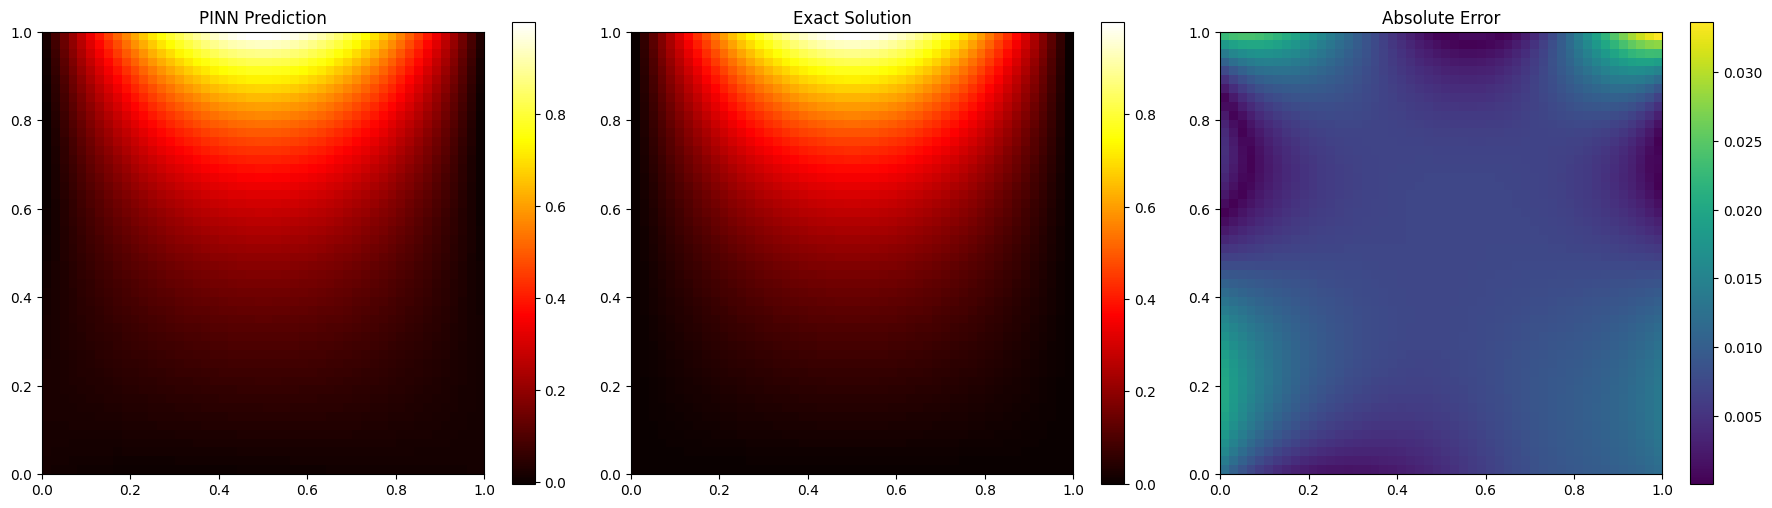

In [ ]:
import numpy as np

# Obtain PINN Prediction
with torch.no_grad():
    x = torch.linspace(0, 1, 50)
    y = torch.linspace(0, 1, 50)
    grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')
    T_pred = pinn_model(grid_x.reshape(-1, 1), grid_y.reshape(-1, 1)).reshape(50, 50).numpy()

# Exact Analytical Solution
# T(x,y) = sin(pi*x) * sinh(pi*y) / sinh(pi)
X_np, Y_np = grid_x.numpy(), grid_y.numpy()
T_exact = np.sin(np.pi * X_np) * (np.sinh(np.pi * Y_np) / np.sinh(np.pi))

# Visualization
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

im0 = ax[0].imshow(T_pred.T, extent=(0, 1, 0, 1), origin='lower', cmap='hot')
ax[0].set_title('PINN Prediction')
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(T_exact.T, extent=(0, 1, 0, 1), origin='lower', cmap='hot')
ax[1].set_title('Exact Solution')
plt.colorbar(im1, ax=ax[1])

error = np.abs(T_pred - T_exact)
im2 = ax[2].imshow(error.T, extent=(0, 1, 0, 1), origin='lower', cmap='viridis')
ax[2].set_title('Absolute Error')
plt.colorbar(im2, ax=ax[2])

plt.tight_layout()
plt.show()

# Conclusion
In this handout, we built and trained simple neural networks for regression and for solving the heat equation. Optimization is a fundamental concept in mechanical engineering, and a neural network serves as a powerful approach to constrained optimization.

Physics-Informed Neural Networks (PINNs) are a specialized class of neural networks where the constraints are derived directly from physical laws. This field has gained significant popularity over the last few years. Our team is actively contributing to this research area through the [Accelerated MultiPhysics Research Group](https://blog.metu.edu.tr/akarakus/).

We encourage you to experiment with the notebook and attempt to optimize more challenging functions. If you have any questions, feel free to stop by during office hours!